# Лабораторная работа №2: Вскрытие «Черного ящика» (Model-Agnostic методы)

## Задание 1: Иллюзия недвижимости (PDP vs ALE)

### Легенда
Вы работаете Data Scientist'ом в крупном агентстве недвижимости. Вы обучили мощный Random Forest для оценки стоимости квартир. Модель отлично работает по метрикам. Бизнес просит вас показать график: **как именно жилая площадь влияет на цену?**

### 1.  **Загрузка**

In [130]:
!pip install interpret numpy pandas scikit-learn matplotlib seaborn

In [131]:
!pip install interpret PyALE

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from PyALE import ale
import seaborn as sns

np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")

In [133]:
# Считываем данные
df1 = pd.read_csv('Task2_1_housing.csv')
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_sqm           1500 non-null   int64  
 1   Num_Rooms          1500 non-null   int64  
 2   Distance_to_metro  1500 non-null   int64  
 3   Floor              1500 non-null   int64  
 4   Price              1500 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 58.7 KB


,Area_sqm,Num_Rooms,Distance_to_metro,Floor,Price
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,84.634667,2.988000,15.509333,12.95800,13858.855053
std,37.607181,1.435234,8.246813,6.90024,6621.510281
min,20.000000,1.000000,1.000000,1.00000,2146.930000
25%,51.000000,2.000000,8.000000,7.00000,8177.782500
50%,84.000000,3.000000,16.000000,13.00000,13894.510000
75%,116.000000,4.000000,23.000000,19.00000,19218.670000
max,162.000000,5.000000,29.000000,24.00000,27014.160000


In [134]:
df1.head()

,Area_sqm,Num_Rooms,Distance_to_metro,Floor,Price
0,105,4,27,13,17206.68
1,136,5,24,10,22516.23
2,95,3,22,3,14347.94
3,124,5,4,9,22178.72
4,136,5,2,12,24305.99


### 2.  **Black-Box**

In [135]:
X1 = df1[['Area_sqm', 'Num_Rooms', 'Distance_to_metro', 'Floor']]
y1 = df1['Price']

#  Обучаем RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X1, y1)

RandomForestRegressor(random_state=42)

### 3.  **Ловушка PDP**

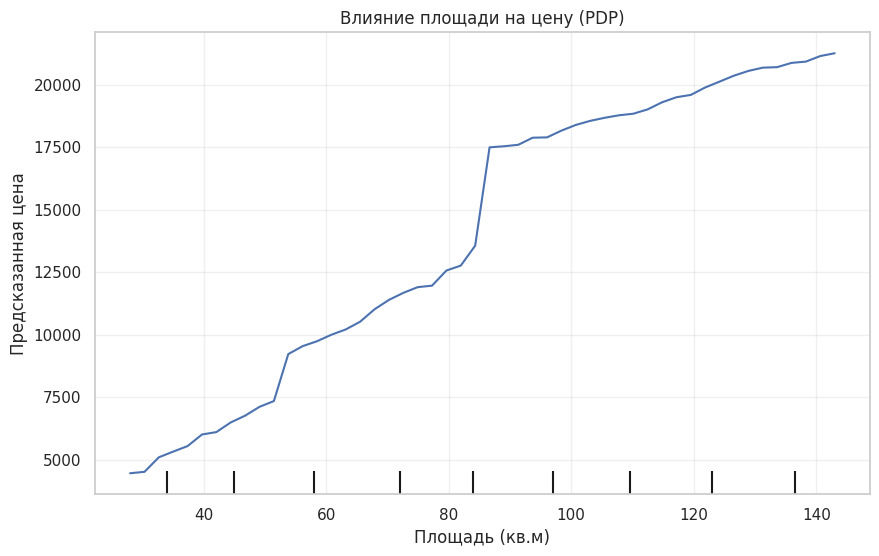

In [136]:
# Строим график Partial Dependence Plot (PDP)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    rf, X1, ['Area_sqm'],
    ax=ax, grid_resolution=50
)
plt.title('Влияние площади на цену (PDP)')
plt.xlabel('Площадь (кв.м)')
plt.ylabel('Предсказанная цена')
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос:** Посмотрите на график. Как ведет себя цена при большой площади? Кажется ли вам этот тренд логичным?

На графике мы видим резкий скачок в цене при площади от ~80 кв.м до ~87 кв.м. А далее при площади более 100 кв.м цена растет достаточно стабильно без резких скачков или снижения стоимости.

Кажется не очнь логичным скачок в цене с 12500 до 17500, при этом с разницей в ~7 кв.м.

###4.  **Анализ данных**

In [137]:
#  Строим scatter-plot зависимости Area_sqm от Num_Rooms
plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
plt.scatter(df1['Area_sqm'], df1['Num_Rooms'], alpha=0.5)
plt.xlabel('Площадь (кв.м)')
plt.ylabel('Количество комнат')
plt.title('Scatter plot')
plt.grid(True, alpha=0.3)

**Вопрос:** Какую фундаментальную ошибку совершил алгоритм PDP, учитывая распределение точек на этом графике?

PDP усредняет проедсказания, игнорируя корреляцию между признаками.

На графике при кв.м от 80 до 90 есть 2-х, 3-х, 4-комнатные квартиры. Это может влиять на цену и резкий скачок на предыдущем графике. Получается PDP сильно много смысла вкладывет в эти выбросы (тип где например двушка 90 кв.м)?

чет я не догоняю, лан потом подумаю


### 5.  **Математически честный подход**

INFO:PyALE._ALE_generic:Continuous feature detected.


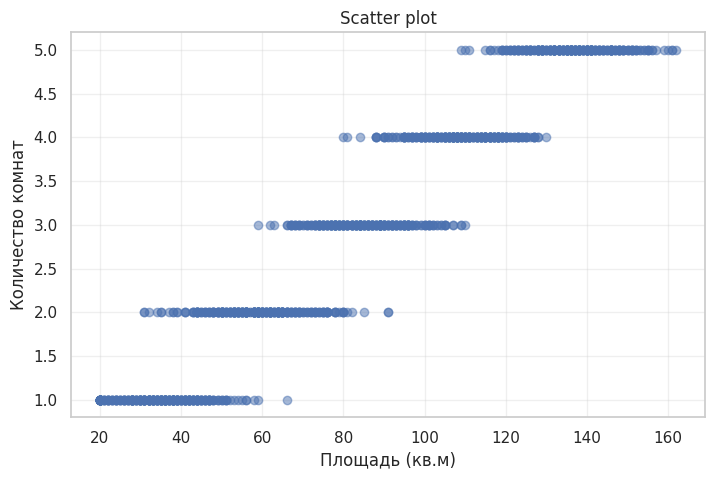

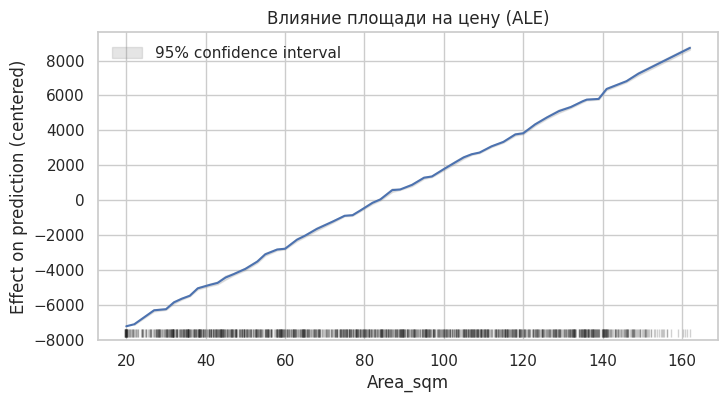

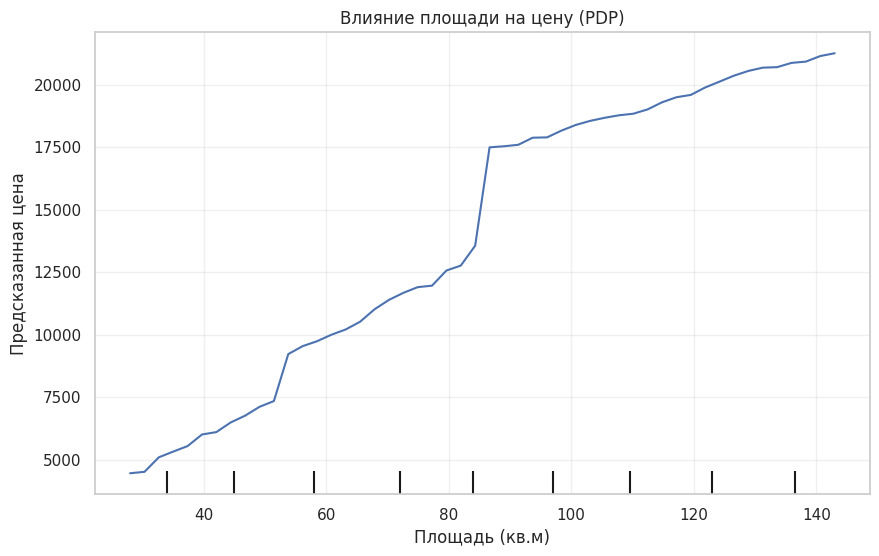

In [138]:
# Строим ALE-plot для признака Area_sqm
ale_plot = ale(
    X=df1[['Area_sqm', 'Num_Rooms', 'Distance_to_metro', 'Floor']],
    model=rf,
    feature=['Area_sqm'],
    grid_size=50,
    include_CI=True
)
plt.title("Влияние площади на цену (ALE)")
plt.show()

# PDP
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    rf, X1, ['Area_sqm'],
    ax=ax,
    grid_resolution=50)
plt.title("Влияние площади на цену (PDP)")
plt.xlabel("Площадь (кв.м)")
plt.ylabel("Предсказанная цена")
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос:** Какой из них вы понесете бизнес-заказчику и как вы обоснуете свой выбор простыми словами?

PDP показывает, как изменится цена, если мы возьмем квартиру и просто увеличим ее площадь, оставив всё остальное неизменным. Но в реальности при увеличении площади обычно увеличивается и количество комнат. ALE учитывает эту взаимосвязь и показывает более реалистичную картину.

## Задание 2: Медицинский консилиум (SHAP и UMAP)

### Легенда
Вы работаете в MedTech-компании. Ваша команда создала градиентный бустинг, который предсказывает риск развития сердечно-сосудистого заболевания. Врачи отказываются использовать модель, потому что она не объясняет свои решения. Главный врач дал вам две задачи: показать, как модель мыслит в целом, и объяснить диагнозы двух конкретных пациентов.


### 1.  **Загрузка**

In [139]:
import shap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap

In [140]:
# Считываем данные
df2 = pd.read_csv('Task2_2_medical.csv')
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           1500 non-null   int64  
 1   Cholesterol   1500 non-null   float64
 2   Weight        1500 non-null   float64
 3   Stress_Level  1500 non-null   int64  
 4   Risk          1500 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 58.7 KB


,Age,Cholesterol,Weight,Stress_Level,Risk
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,51.222000,5.468440,79.957733,4.928667,0.408667
std,15.703453,1.240163,15.445183,2.569821,0.491751
min,25.000000,1.480000,32.900000,1.000000,0.000000
25%,38.000000,4.630000,69.600000,3.000000,0.000000
50%,50.000000,5.465000,80.150000,5.000000,0.000000
75%,65.000000,6.310000,90.600000,7.000000,1.000000
max,79.000000,9.430000,133.200000,9.000000,1.000000


In [141]:
df2.head()

,Age,Cholesterol,Weight,Stress_Level,Risk
0,49,6.30,98.8,3,1
1,27,5.67,66.0,4,0
2,33,4.50,69.1,3,0
3,46,7.58,66.6,7,1
4,47,4.21,62.9,7,0


### 2.  **Обучение**

In [142]:
# Разделяем данные
X2 = df2[['Age', 'Cholesterol', 'Weight', 'Stress_Level']]
y2 = df2['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1200, 4)
Размер тестовой выборки: (300, 4)


In [143]:
# Обучаем GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

accuracy = gb.score(X_test, y_test)
print(f"Точность модели: {accuracy:.3f}")

Точность модели: 0.950


### 3.  **Глобальный SHAP**

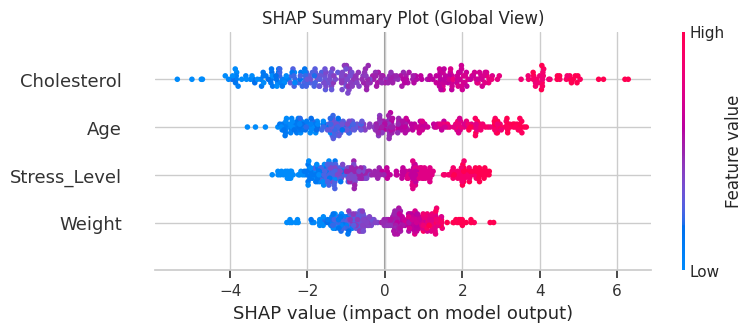

In [144]:
# Используем shap и TreeExplainer
explainer = shap.Explainer(gb, X_test)
shap_explanation = explainer(X_test, check_additivity=False)

# Глобальное объяснение (Summary/Beeswarm plot)
shap.plots.beeswarm(shap_explanation, show=False)
plt.title("SHAP Summary Plot (Global View)")
plt.show()

**Вопрос:** Опишите словами, как возраст (`Age`) и уровень стресса (`Stress_Level`) влияют на риск заболевания. Какие закономерности (направление влияния, разброс) вы видите на графике?

Возраст (Age): Точки красного цвета (высокий возраст) расположены преимущественно справа от нулевой линии, что говорит о повышении риска заболевания с возрастом. Низкий возраст снижает риск. Разброс значений довольно широкий. Чем старше пациент, тем выше вклад этого признака в предсказание болезни.

Уровень стресса (Stress_Level): Высокий стресс является фактором риска. Разброс также присутствует. С увеличением уровня стресса увеличивается риск заболевания.

### 4.  **Локальный SHAP**

In [145]:
# Получаем предсказанные вероятности для тестовой выборки
predicted_probs = gb.predict_proba(X_test)[:, 1] # Вероятность класса 1 (риск)

# Индекс пациента с самым высоким риском
high_risk_idx = np.argmax(predicted_probs)
# Индекс пациента с самым низким риском
low_risk_idx = np.argmin(predicted_probs)

print(f"Пациент с самым высоким риском (индекс {high_risk_idx}): {predicted_probs[high_risk_idx]:.3f}")
print(f"Реальные значения признаков:")
for col in X_test.columns:
    print(f"  {col}: {X_test.iloc[high_risk_idx][col]}")

print(f"Пациент с самым низким риском (индекс {low_risk_idx}): {predicted_probs[low_risk_idx]:.3f}")
print(f"Реальные значения признаков:")
for col in X_test.columns:
    print(f"  {col}: {X_test.iloc[low_risk_idx][col]}")

Пациент с самым высоким риском (индекс 122): 0.999
Реальные значения признаков:
  Age: 74.0
  Cholesterol: 6.35
  Weight: 107.9
  Stress_Level: 9.0
Пациент с самым низким риском (индекс 142): 0.001
Реальные значения признаков:
  Age: 25.0
  Cholesterol: 4.43
  Weight: 48.7
  Stress_Level: 1.0


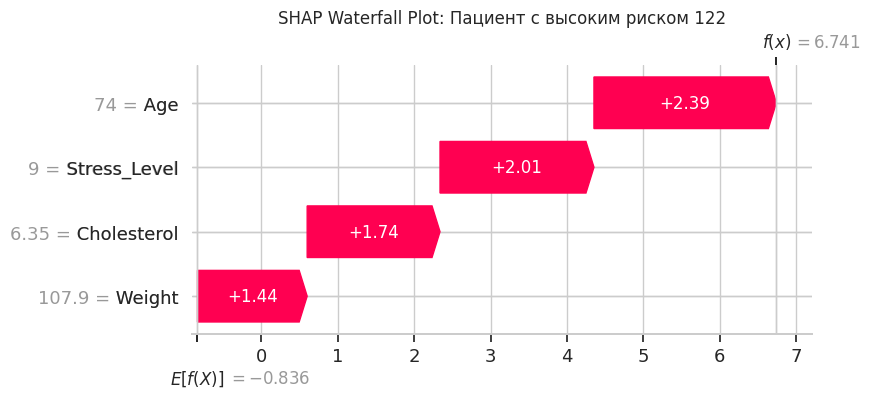

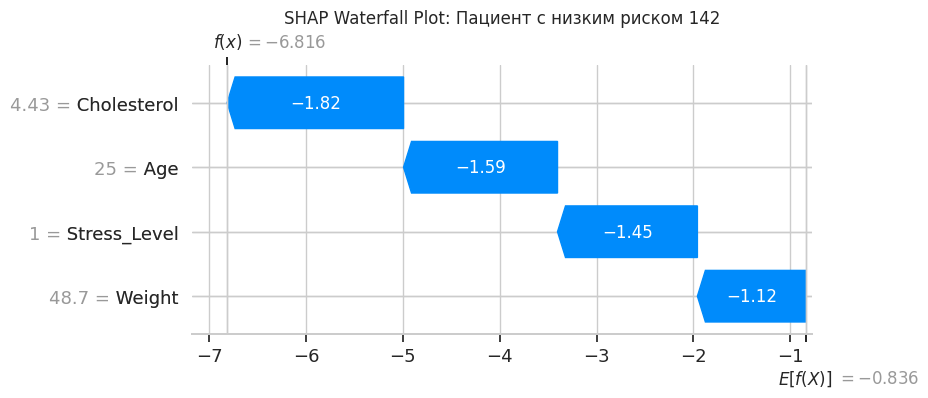

In [146]:
# Локальное объяснение (Waterfall plot)
shap.plots.waterfall(shap_explanation[high_risk_idx], show=False)
plt.title(f"SHAP Waterfall Plot: Пациент с высоким риском {high_risk_idx}")
plt.show()

shap.plots.waterfall(shap_explanation[low_risk_idx], show=False)
plt.title(f"SHAP Waterfall Plot: Пациент с низким риском {low_risk_idx}")
plt.show()

**Задание:** Напишите "медицинское заключение" (2-3 предложения) для каждого пациента: какие конкретно факторы перевесили чашу весов в сторону болезни или здоровья?

#### 1.  Пациент с высоким риском
У данного пациента наблюдается высокий риск сердечно-сосудистой патологии. Ключевыми факторами, повлиявшими на высокий прогноз, являются пожилой возраст (74), высокий уровень холестерина (6.35) и повышенный уровень стресса (9). Рекомендовано обследование и коррекция образа жизни.

#### 2.  Пациент с высоким риском
Прогнозируемый риск развития сердечно-сосудистых заболеваний минимальный. Молодой возраст (25) пациента и низкий уровень стресса (1) - главный залог низкого показателя. Вес (48.7) и холестерин (4.43) также находятся в пределах значений, способствующих снижению общего риска.

### 5.  **Визуализация пространства (UMAP)**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


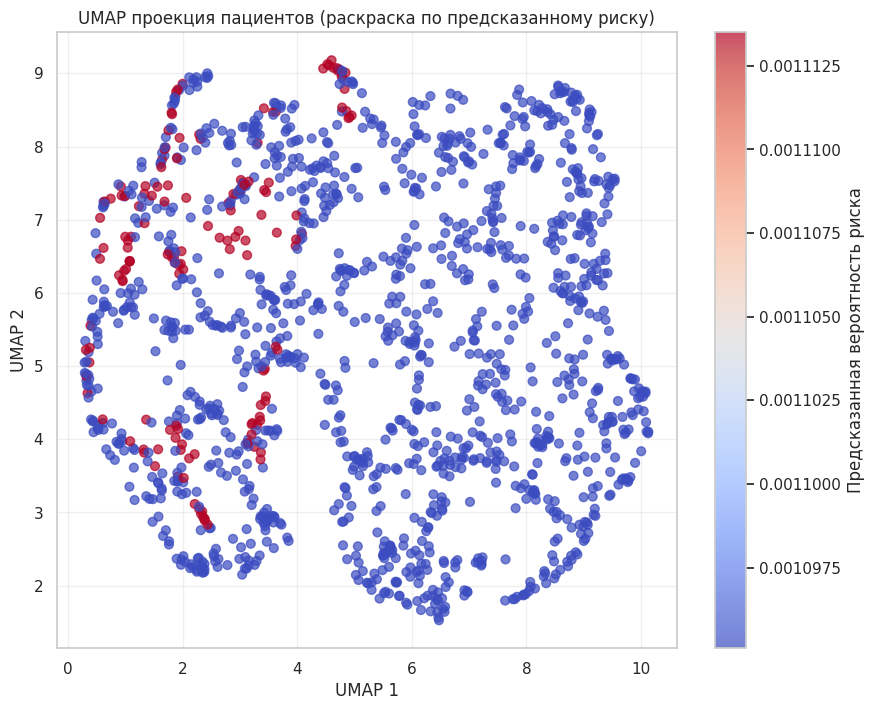

In [147]:
# Масштабируем все данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2.drop('Risk', axis=1))

reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Получаем предсказания модели для всех данных для раскраски
predicted_probs_scaled = gb.predict_proba(pd.DataFrame(X_scaled, columns=X2.columns))[:, 1]

# Построение scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=predicted_probs_scaled,
                      cmap='coolwarm', s=40, alpha=0.7)
plt.colorbar(scatter, label='Предсказанная вероятность риска')
plt.title('UMAP проекция пациентов (раскраска по предсказанному риску)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос:** Видите ли вы четкие кластеры больных и здоровых людей?

На графике UMAP видно, что пациенты не перемешаны хаотично. Формируются два крупных кластера.

Один кластер (справа) содержит только точки синего цвета, соответствующие пациентам с низким предсказанным риском.

Другой кластер (левая часть) состоит из точек красного и синего цвета. Думаю можно определить его как кластер пациентов с высоким риском и около высоким (если присваивать не бинарное значение признаку Risk).